# Ancillary Fund Pool Redistribution — Layer 1 Model

**What this notebook does:** models who could access the ~$1.5bn/yr pool of ancillary fund (PAF/PuAF) distributions under four DGR scenarios × three allocation rules.

**The scenario × rule matrix:**

| | Donations rule | Revenue rule | Count rule |
|---|---|---|---|
| **Status quo** (no change) | | | |
| **PC proposal** (pure change: gainers + losers) | | | |
| **Unlock proposal** (expansion: gainers, no losers) | | | |
| **Universal DGR** (every charity eligible) | | | |

- **Rules** (columns): ancillary funds' recipient-level flows are never published, so each scenario assumes a mechanical sharing rule — pool split in proportion to *donations received*, *total revenue*, or *equally per charity*.
- **Scenarios** (rows): who is inside the eligible base. PC and Unlock eligibility comes from the team's charity-level mapping (`output_dgr_change_mapping.xlsx`); Universal DGR is the outer bound.

**Data dependencies** (R `targets` pipeline snapshot 2026-07-21):
- `data/analytical/ancillary_funds_timeseries.csv` — the pool (ATO Taxation Statistics, charities Table 4)
- `data/analytical/dgr_gap_analysis.parquet` — charity-level financials + DGR status (latest AIS year)
- `analysis/ancillary_redistribution/output_dgr_change_mapping.xlsx` — per-charity reform eligibility flags

> ⚠️ These are **access scenarios, not predicted flows**. Fixed-pool view: gains for newly eligible charities come out of incumbents' share (Layer 1). Pie growth from increased giving is Layer 2 — see the event study.


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Resolve paths whether run from this folder, analysis/, or the repo root
HERE = next(p for p in [Path("."), Path("analysis/ancillary_redistribution"),
                        Path("ancillary_redistribution")]
            if (p / "output_dgr_change_mapping.xlsx").exists())
DATA = next(p for p in [HERE / "../../data/analytical", Path("data/analytical")]
            if p.exists())

pd.options.display.float_format = "{:,.2f}".format

# ---- shared design system ---------------------------------------------------
C = {
    "paf": "#1b6ca8",        # PAF (dark blue)
    "puaf": "#7fb3d5",       # PuAF (light blue)
    "incumbent": "#25605f",  # current DGRs (teal)
    "new": "#e8702a",        # newly eligible (orange)
    "outside": "#d9d9d9",    # non-DGR (light grey)
    "neg": "#b3402a",
}
RULE_ORDER = ["donations", "revenue", "count"]
RULE_LABEL = {"donations": "Donations rule", "revenue": "Revenue rule", "count": "Count rule"}
RULE_COLOR = {"donations": "#1b6ca8", "revenue": "#25605f", "count": "#e8702a"}
SCEN_ORDER = ["Status quo", "PC proposal", "Unlock proposal", "Universal DGR"]

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.frameon": False,
    "font.size": 10,
})

def fmt_m(ax, axis="y", dec=0):
    """$m tick labels on the chosen axis."""
    getattr(ax, f"{axis}axis").set_major_formatter(
        mtick.StrMethodFormatter(f"${{x:,.{dec}f}}m")
    )


## Step 1 — The pool: what ancillary funds distribute

Ancillary funds (private = PAF, public = PuAF) are **Item 2 DGRs**: tax-advantaged giving vehicles whose distributions are legally restricted to **Item 1 DGRs**. The ATO publishes aggregate donations in, distributions out, and net assets per year (Taxation Statistics, charities Table 4).


In [2]:
anc = pd.read_csv(DATA / "ancillary_funds_timeseries.csv")

latest_fy = anc["income_year"].max()
latest = anc[anc["income_year"] == latest_fy]
POOL = latest["distributions_made"].sum()

summary = latest.set_index("fund_type")[
    ["n_funds", "donations_received", "distributions_made", "net_assets"]
].copy()
summary.loc["Total"] = summary.sum()
summary["payout_rate_%"] = 100 * summary["distributions_made"] / summary["net_assets"]

print(f"Pool ({latest_fy} PAF+PuAF distributions): ${POOL/1e6:,.0f}m")
summary


Pool (2023-24 PAF+PuAF distributions): $1,527m


,n_funds,donations_received,distributions_made,net_assets,payout_rate_%
fund_type,,,,,
PAF,2289,1116937761,914435664,13265693532,6.89
PuAF,1425,632761448,612830300,4266227180,14.36
Total,3714,1749699209,1527265964,17531920712,8.71


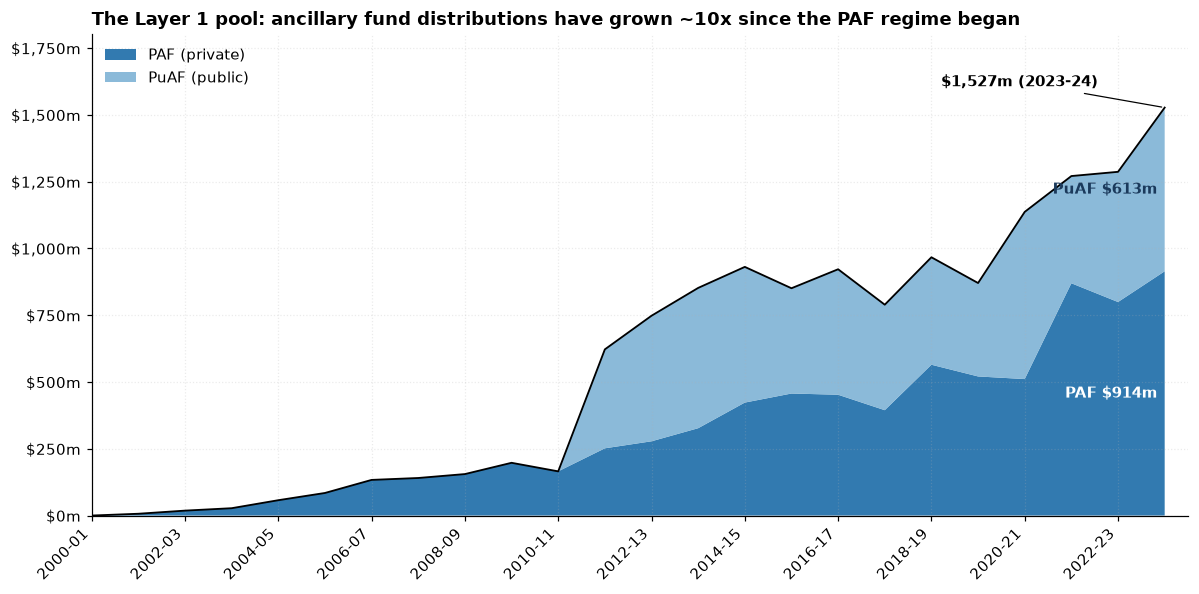

PAFs cluster near their 5% minimum payout; PuAFs pay well above their 4% minimum.


In [3]:
# Pool trend: distributions out by fund type
trend = anc.pivot_table(
    index="income_year", columns="fund_type",
    values="distributions_made", aggfunc="sum",
).fillna(0)[["PAF", "PuAF"]] / 1e6

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(trend))
ax.stackplot(
    x, trend["PAF"], trend["PuAF"],
    labels=["PAF (private)", "PuAF (public)"],
    colors=[C["paf"], C["puaf"]], alpha=0.9,
)
tot = trend.sum(axis=1)
ax.plot(x, tot, color="black", lw=1.2)

# annotate the latest year (the pool used in this model)
ax.annotate(
    f"${tot.iloc[-1]:,.0f}m ({trend.index[-1]})",
    xy=(x[-1], tot.iloc[-1]), xytext=(-95, 14), textcoords="offset points",
    fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
)
# annotate split of latest year inside the bands
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] / 2, f"PAF ${trend['PAF'].iloc[-1]:,.0f}m",
        ha="right", va="center", color="white", fontweight="bold")
ax.text(x[-1] - 0.15, trend["PAF"].iloc[-1] + trend["PuAF"].iloc[-1] / 2,
        f"PuAF ${trend['PuAF'].iloc[-1]:,.0f}m", ha="right", va="center",
        color="#1b3a5c", fontweight="bold")

ax.set_xticks(x[::2], trend.index[::2], rotation=45, ha="right")
ax.set_xlim(0, len(trend) - 0.5)
ax.set_ylim(0, tot.max() * 1.18)
ax.margins(x=0)
fmt_m(ax)
ax.set_title("The Layer 1 pool: ancillary fund distributions have grown ~10x since the PAF regime began")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("PAFs cluster near their 5% minimum payout; PuAFs pay well above their 4% minimum.")


## Step 2 — The recipient base and the three allocation rules

The recipient base is every charity with financials in the latest AIS year, **ancillary funds themselves excluded** (a PAF cannot fund another PAF). Today only DGR-endorsed charities can receive the pool.

We cannot observe who actually receives it, so each scenario assumes a mechanical sharing rule. For eligible set $E$, charity weights $w_i$, and pool $P$, a group $G \subseteq E$ receives:

$$\text{dollars}(G) = P \times \frac{\sum_{i \in G} w_i}{\sum_{j \in E} w_j}, \qquad w_i \in \{d_i \text{ (donations)},\; r_i \text{ (revenue)},\; 1 \text{ (count)}\}$$

- **donations** — proportional to demonstrated fundability (most plausible: ancillary grants arrive as donations)
- **revenue** — proportional to organisational scale
- **count** — equal scoop per charity (upper bound for numerous small charities)

Scenarios differ only in $E$. Same rule, different fence.


In [4]:
gap = pd.read_parquet(DATA / "dgr_gap_analysis.parquet")

latest_yr = gap["ais_year"].max()
base = gap[gap["ais_year"] == latest_yr].copy()
base["revenue"] = base["total_gross_income"].fillna(0).clip(lower=0)
base["donations"] = base["donations_and_bequests"].fillna(0).clip(lower=0)

def weights(df):
    """Total weight of a charity set under each allocation rule."""
    return pd.Series(
        {"donations": df["donations"].sum(), "revenue": df["revenue"].sum(), "count": len(df)}
    )

dgr_base = base[base["has_dgr"]]

fence = pd.DataFrame({
    "DGR (inside fence)": weights(dgr_base),
    "non-DGR (outside)": weights(base[~base["has_dgr"]]),
})
fence["DGR share %"] = 100 * fence["DGR (inside fence)"] / fence.sum(axis=1)
print(f"Latest AIS year: {latest_yr} | recipient base: {len(base):,} charities")
fence


Latest AIS year: 2024 | recipient base: 49,914 charities


,DGR (inside fence),non-DGR (outside),DGR share %
donations,"9,172,295,776.00","2,596,522,214.00",77.94
revenue,"151,840,198,100.00","93,466,686,179.00",61.90
count,"20,107.00","29,807.00",40.28


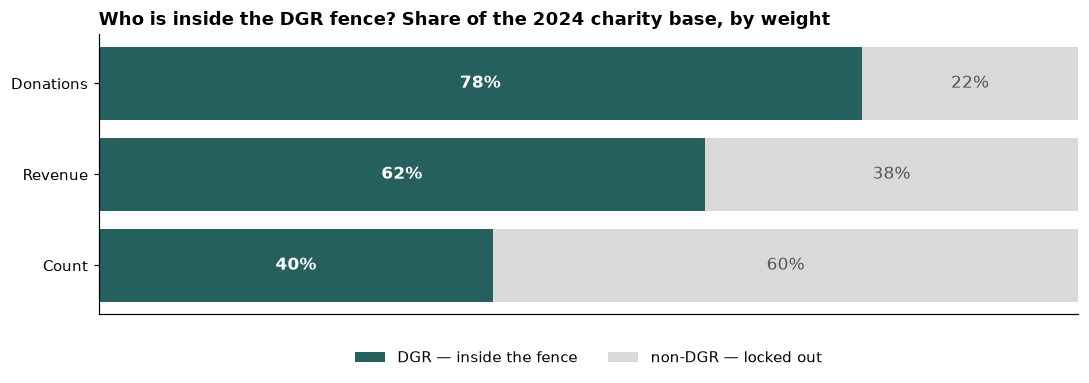

DGR charities are only ~40% by count but ~62% of revenue and ~78% of donations:
endorsement is concentrated among larger, donation-attracting charities.


In [5]:
# The fence as a 100%-stacked bar: inside vs outside, under each weighting
share = fence["DGR share %"].reindex(RULE_ORDER)

fig, ax = plt.subplots(figsize=(10, 3.6))
y = np.arange(len(share))
ax.barh(y, share, color=C["incumbent"], label="DGR — inside the fence")
ax.barh(y, 100 - share, left=share, color=C["outside"], label="non-DGR — locked out")

for i, v in enumerate(share):
    ax.text(v / 2, i, f"{v:.0f}%", va="center", ha="center",
            color="white", fontweight="bold", fontsize=11)
    ax.text(v + (100 - v) / 2, i, f"{100 - v:.0f}%", va="center", ha="center",
            color="#555", fontsize=11)

ax.set_yticks(y, [RULE_LABEL[r].replace(" rule", "") for r in share.index])
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.grid(False)
ax.set_title(f"Who is inside the DGR fence? Share of the {latest_yr} charity base, by weight")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncols=2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(
    "DGR charities are only ~40% by count but ~62% of revenue and ~78% of donations:\n"
    "endorsement is concentrated among larger, donation-attracting charities."
)


## Step 3 — The four scenarios

Eligibility comes from the team's charity-level mapping (`output_dgr_change_mapping.xlsx`), which flags each charity's DGR status under the PC redesign and the expansion variant. The recipient universe is the latest-AIS-year base above (charities without current financials cannot be weighted, so they are excluded from every scenario consistently).

| Scenario | Eligible base $E$ | Groups |
|---|---|---|
| **Status quo** | current DGRs | incumbents only |
| **PC proposal** (pure change) | mapping `dgr_reform_status = Y` | incumbents who keep DGR + gainers; **losers exit** |
| **Unlock proposal** (expansion) | current DGRs + mapping `dgr_reform_status_expansion = Y` | incumbents + gainers; nobody exits |
| **Universal DGR** | every charity | incumbents + gainers (outer bound) |

> **Ancillary-fund override:** the mapping flags ~1,200 ancillary funds as PC losers, but the PC final report (*Future Foundations for Giving*, 2024) retains ancillary funds ("giving funds") with DGR intact — its removals target *recipient* activity classes, not Item 2 giving vehicles. We treat those flags as a mapping artefact: the $1,527m pool is assumed intact under every scenario. (Ancillary funds are already excluded from the recipient base, so this only affects the pool's existence, not the splits.)


In [6]:
# Load the mapping (one row per ABN: latest ais_year flags win) and join to the base
mapping = pd.read_excel(HERE / "output_dgr_change_mapping.xlsx", dtype={"abn": str})
mapping = mapping[mapping["abn"].str.fullmatch(r"\d{11}", na=False)]
mapping = (
    mapping.sort_values("ais_year")
    .groupby("abn", as_index=False)
    .last()[["abn", "is_ancillary", "has_dgr", "dgr_reform_status", "dgr_reform_status_expansion"]]
    .rename(columns={"dgr_reform_status": "pc", "dgr_reform_status_expansion": "exp"})
)
n_anc_override = int((mapping["is_ancillary"].astype(bool)
                      & (mapping["has_dgr"] == "Y") & (mapping["pc"] == "N")).sum())
print(f"Ancillary funds flagged as PC losers, overridden to retain DGR: {n_anc_override:,}")

m = base.merge(mapping[["abn", "pc", "exp"]], on="abn", how="left")
assert m[["pc", "exp"]].notna().all().all(), "every base charity should be in the mapping"
m[["pc", "exp"]] = m[["pc", "exp"]] == "Y"

# eligible mask and gainer mask per scenario (incumbents = eligible current DGRs)
SCENARIOS = {
    "Status quo":      (m["has_dgr"],              m["has_dgr"] & False),
    "PC proposal":     (m["pc"],                   m["pc"] & ~m["has_dgr"]),
    "Unlock proposal": (m["has_dgr"] | m["exp"],   m["exp"] & ~m["has_dgr"]),
    "Universal DGR":   (pd.Series(True, m.index),  ~m["has_dgr"]),
}

counts = pd.DataFrame({
    name: {"eligible": int(elig.sum()),
           "incumbents": int((elig & m["has_dgr"]).sum()),
           "gainers": int(gain.sum()),
           "losers (exit)": int((m["has_dgr"] & ~elig).sum())}
    for name, (elig, gain) in SCENARIOS.items()
}).T
counts


Ancillary funds flagged as PC losers, overridden to retain DGR: 1,209


,eligible,incumbents,gainers,losers (exit)
Status quo,20107,20107,0,0
PC proposal,30418,17401,13017,2706
Unlock proposal,33124,20107,13017,0
Universal DGR,49914,20107,29807,0


## Step 4 — The result: scenario × rule matrix

For each scenario the fixed pool splits between **incumbents** (current DGRs still eligible) and **gainers** (newly eligible). Under PC pure change the ~2,700 losers exit the base, so we also quantify the pool share **displaced** from them.


In [7]:
# Scenario engine: split the fixed pool between incumbents and gainers under each rule
rows = []
for name, (elig, gain) in SCENARIOS.items():
    w_elig = weights(m[elig])
    w_gain = weights(m[gain])
    w_inc = weights(m[elig & m["has_dgr"]])
    for rule in RULE_ORDER:
        rows.append({
            "scenario": name, "rule": rule,
            "incumbent_$m": POOL * w_inc[rule] / w_elig[rule] / 1e6,
            "gainer_$m": POOL * w_gain[rule] / w_elig[rule] / 1e6,
            "gainer_share_%": 100 * w_gain[rule] / w_elig[rule],
        })
res = pd.DataFrame(rows)

# Displaced dollars (PC only): what losers would receive today under each rule
w_today = weights(m[m["has_dgr"]])
losers = m[m["has_dgr"] & ~SCENARIOS["PC proposal"][0]]
displaced = pd.Series({r: POOL * weights(losers)[r] / w_today[r] / 1e6 for r in RULE_ORDER},
                      name="displaced_from_PC_losers_$m")
print(f"PC losers ({len(losers):,} charities) receive today, by rule — displaced by pure change:")
print(displaced.round(0).to_string(), "\n")

# THE MATRIX: gainer access $m/yr (share of pool in brackets)
matrix = res.pivot(index="scenario", columns="rule", values="gainer_$m").reindex(SCEN_ORDER)[RULE_ORDER]
shares = res.pivot(index="scenario", columns="rule", values="gainer_share_%").reindex(SCEN_ORDER)[RULE_ORDER]
print(f"Newly-eligible access to the ${POOL/1e6:,.0f}m pool, $m/yr (% of pool):")
matrix.round(0).astype(int).astype(str) + "  (" + shares.round(0).astype(int).astype(str) + "%)"


PC losers (2,706 charities) receive today, by rule — displaced by pure change:
donations   163.00
revenue     152.00
count       206.00 

Newly-eligible access to the $1,527m pool, $m/yr (% of pool):


rule,donations,revenue,count
scenario,,,
Status quo,0 (0%),0 (0%),0 (0%)
PC proposal,121 (8%),542 (35%),654 (43%)
Unlock proposal,109 (7%),506 (33%),600 (39%)
Universal DGR,337 (22%),582 (38%),912 (60%)


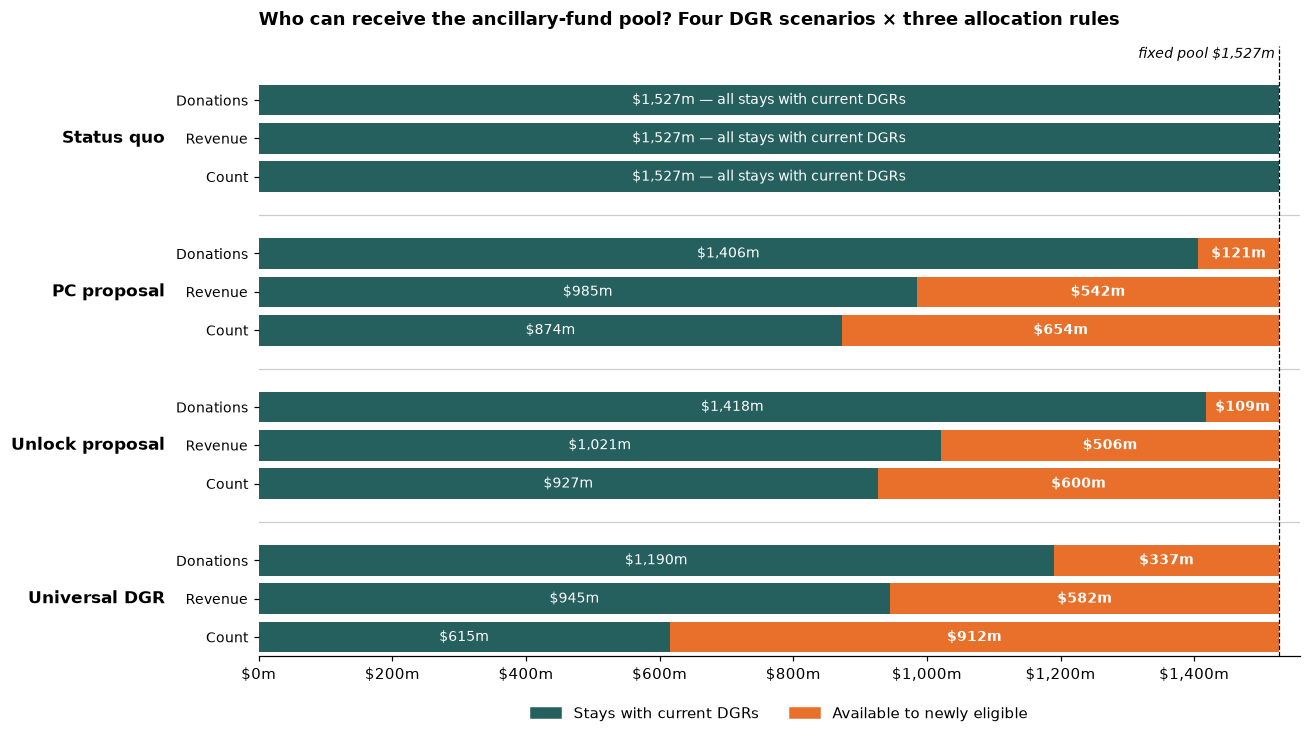

In [9]:
# Hero chart: the fixed pool under all four scenarios, by allocation rule
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6.8))
GAPH = 1.0  # gap between scenario groups
ypos, ylabels, dividers = [], [], []
yc = 0.0
for scen_name in SCEN_ORDER:
    d = res[res["scenario"] == scen_name].set_index("rule").reindex(RULE_ORDER)
    for rule in RULE_ORDER:
        inc, gn = d.loc[rule, "incumbent_$m"], d.loc[rule, "gainer_$m"]
        ax.barh(yc, inc, color=C["incumbent"])
        ax.barh(yc, gn, left=inc, color=C["new"])
        if gn > 0:
            ax.text(inc + gn / 2, yc, f"${gn:,.0f}m", va="center", ha="center",
                    color="white", fontweight="bold", fontsize=9)
            ax.text(inc / 2, yc, f"${inc:,.0f}m", va="center", ha="center",
                    color="white", fontsize=9)
        else:
            ax.text(inc / 2, yc, f"${inc:,.0f}m — all stays with current DGRs",
                    va="center", ha="center", color="white", fontsize=9)
        ypos.append(yc)
        ylabels.append(RULE_LABEL[rule].replace(" rule", ""))
        yc += 1
    # scenario label left of the rule tick labels (x in axes fraction, y in data)
    ax.text(-0.09, yc - 2, scen_name, transform=ax.get_yaxis_transform(),
            fontweight="bold", fontsize=11, ha="right", va="center")
    dividers.append(yc - 0.5)
    yc += GAPH

for dv in dividers[:-1]:
    ax.axhline(dv + GAPH / 2, color="#ccc", lw=0.8)
ax.axvline(POOL / 1e6, color="black", lw=0.8, ls="--")
ax.text(POOL / 1e6, -1.1, f"fixed pool ${POOL/1e6:,.0f}m ", ha="right", fontsize=9,
        style="italic")

ax.set_yticks(ypos, ylabels, fontsize=9)
ax.set_xlim(0, POOL / 1e6 * 1.02)
ax.set_ylim(yc - GAPH - 0.5, -1.4)
fmt_m(ax, "x")
ax.grid(False)
ax.spines["left"].set_visible(False)
ax.set_title("Who can receive the ancillary-fund pool? Four DGR scenarios × three allocation rules",
             pad=14)
ax.legend(handles=[Patch(color=C["incumbent"], label="Stays with current DGRs"),
                   Patch(color=C["new"], label="Available to newly eligible")],
          loc="upper center", bbox_to_anchor=(0.5, -0.06), ncols=2)
plt.tight_layout()
plt.show()


## Step 5 — Reality check: which rules are plausible?

The ATO never publishes who receives ancillary distributions, but when a fund grants to a charity the recipient reports it inside **donations and bequests** in its AIS. So a group's *actual reported donations* is a hard ceiling on what it could plausibly absorb from ancillary funds.

The pool is **~17% of all donations reported by DGR charities**. Under the *donations rule* every group's modelled receipt is pinned at that anchor and can never breach the ceiling. The *revenue* and *count* rules ignore what charities actually attract, so the check below flags where modelled gainer receipts exceed the gainers' entire reported donations — a sign that rule is an access bound, not a likely flow.


In [10]:
# Plausibility: modelled gainer receipts vs gainers' actual reported donations
ANCHOR = 100 * POOL / dgr_base["donations"].sum()
print(f"Anchor: pool ÷ all DGR donations = {ANCHOR:.1f}%\n")

rc = []
for name, (elig, gain) in SCENARIOS.items():
    if name == "Status quo":
        continue
    actual_don = m.loc[gain, "donations"].sum() / 1e6
    for rule in RULE_ORDER:
        modelled = res.loc[(res["scenario"] == name) & (res["rule"] == rule), "gainer_$m"].iloc[0]
        rc.append({
            "scenario": name, "rule": rule,
            "modelled_gainer_$m": modelled,
            "gainers_actual_donations_$m": actual_don,
            "modelled_as_%_of_actual": 100 * modelled / actual_don,
        })
rc = pd.DataFrame(rc)
rc["plausible"] = np.where(rc["modelled_as_%_of_actual"] <= 100, "yes", "NO — exceeds ceiling")
rc.round(1)


Anchor: pool ÷ all DGR donations = 16.7%



,scenario,rule,modelled_gainer_$m,gainers_actual_donations_$m,modelled_as_%_of_actual,plausible
0,PC proposal,donations,121.20,706.00,17.20,yes
1,PC proposal,revenue,542.00,706.00,76.80,yes
2,PC proposal,count,653.60,706.00,92.60,yes
3,Unlock proposal,donations,109.20,706.00,15.50,yes
4,Unlock proposal,revenue,506.00,706.00,71.70,yes
5,Unlock proposal,count,600.20,706.00,85.00,yes
6,Universal DGR,donations,337.00,"2,596.50",13.00,yes
7,Universal DGR,revenue,581.90,"2,596.50",22.40,yes
8,Universal DGR,count,912.00,"2,596.50",35.10,yes


## Results

**The matrix — newly-eligible access to the $1,527m pool, $m/yr (% of pool):**

| Scenario | Donations rule | Revenue rule | Count rule |
|---|---|---|---|
| **Status quo** | $0m | $0m | $0m |
| **PC proposal** | $121m (8%) | $542m (35%) | $654m (43%) |
| **Unlock proposal** | $109m (7%) | $506m (33%) | $600m (39%) |
| **Universal DGR** | $337m (22%) | $582m (38%) | $912m (60%) |

1. **The pool is $1,527m/yr (2023-24)** — $914m from PAFs, $613m from PuAFs — on net assets of $17.5bn and growing. It holds under every scenario because ancillary funds retain their DGR (see the override note in Step 3).
2. **Under the Unlock (expansion) proposal, the ~13,000 gainers with current financials could access $109m–$600m/yr** depending on how funds allocate. The donations rule (most plausible — funds follow demonstrated fundability) gives the low end; the count rule is an upper bound on access, not a likely flow.
3. **The PC pure-change variant is marginally more redistributive** ($121m–$654m) because the ~2,700 losers exit the base — but it also **displaces ~$150–210m/yr** those charities can receive today. The Unlock expansion avoids that displacement entirely at a cost of only ~$10–50m/yr less for gainers.
4. **Universal DGR is the outer bound**: even with every charity eligible, gainers' access tops out at 60% of the pool (count rule) because incumbents hold most of the weight under any scale-based rule.
5. **Reality check passes:** in every scenario × rule cell, modelled gainer receipts stay under the gainers' actual reported donations (the hard ceiling for ancillary money) — though the PC count-rule figure sits at 93% of that ceiling, underlining that count-rule numbers are access bounds.
6. The model is deliberately mechanical: real granting is relationship-driven and lumpy, so these figures bound **access, not flows**. Pie growth from newly endorsed charities attracting more giving is Layer 2 — the event study finds a one-off ~+30% real donations step after endorsement.
